In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

2026-01-18 12:18:18.657805: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-18 12:18:19.161847: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-18 12:18:20.963468: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.p

## ML

In [12]:
"""
train_regime_model.py
---------------------
Train ONE regime model with horizon as a feature.
Model type is pluggable: Gradient Boosting or Neural Net.

This script:
- Uses deseasonalized VPD anomalies
- Trains on all horizons (1–12)
- Includes horizon explicitly as an input
- Trains ONE model for ONE target-month regime
"""


# =========================
# CONFIG
# =========================
CSV_PATH = Path("full_data.csv")
DATE_COL = "Yrmo"          # YYYYMM
TARGET_COL = "VPD"        # change to "VPD" if needed

MAX_HORIZON = 12
MODEL_TYPE = "nn"          # "gb" or "nn"

REGIME_NAME = "oct"
REGIME_MONTHS = {10}        # October

FEATURE_COLS = ["F1","F2","F3","F4","F5","F6"]        # set explicitly or auto-detect

RANDOM_STATE = 42
REGIME_DEFS = {
    "jan": {1},
    "feb": {2},
    "mar": {3},
    "apr": {4},
    "may": {5},
    "jun": {6},
    "jul": {7},
    "aug": {8},
    "sep": {9},
    "oct": {10},
    "nov": {11},
    "dec": {12},
}

all_results = []


# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)

df["date"] = pd.to_datetime(df[DATE_COL].astype(str) + "01", format="%Y%m%d")
df["month"] = df["date"].dt.month
df = df.sort_values("date").reset_index(drop=True)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found")

# =========================
# CALCULATE MONTHLY STATS FOR NORMALIZATION
# =========================

monthly_stats_por = (
    df.assign(month=df["Yrmo"] % 100)
      .groupby("month")["VPD"]
      .agg(mean_VPD="mean", std_VPD="std")
)

print("Monthly stats (full POR):")
print(monthly_stats_por)
# =========================
# DESEASONALIZE TARGET
# =========================
monthly_mean = df.groupby("month")[TARGET_COL].mean()
df["target_anom"] = df[TARGET_COL] - df["month"].map(monthly_mean)

# =========================
# FEATURE SELECTION
# =========================
if FEATURE_COLS is None:
    exclude = {
        DATE_COL, "date", "month",
        TARGET_COL, "target_anom"
    }
    FEATURE_COLS = [
        c for c in df.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(df[c])
    ]

if not FEATURE_COLS:
    raise RuntimeError("No numeric feature columns found")

print(f"Using {len(FEATURE_COLS)} features:")
print(FEATURE_COLS)

for REGIME_NAME, REGIME_MONTHS in REGIME_DEFS.items():

    print(f"\n=== Running regime: {REGIME_NAME} ===")



    # =========================
    # SCALE FEATURES & TARGET
    # =========================
    x_scaler = StandardScaler()
    X_all = x_scaler.fit_transform(df[FEATURE_COLS].values.astype(np.float32))

    y_scaler = StandardScaler()
    y_all = y_scaler.fit_transform(
        df[["target_anom"]].values.astype(np.float32)
    ).ravel()

    # =========================
    # BUILD SUPERVISED PAIRS
    # =========================
    X_list = []
    y_list = []
    meta_month = []
    meta_horizon = []
    n = len(df)
    meta_date = []
    for t in range(n):
        x_t = X_all[t]

        for h in range(1, MAX_HORIZON + 1):
            j = t + h
            if j >= n:
                continue

            target_month = int(df.loc[j, "month"])
            if target_month not in REGIME_MONTHS:
                continue

            # horizon as feature (scaled)
            h_feat = np.array([h / MAX_HORIZON], dtype=np.float32)

            X_list.append(np.concatenate([x_t, h_feat]))
            y_list.append(y_all[j])
            meta_month.append(target_month)
            meta_horizon.append(h)
            meta_date.append(df.loc[j, "date"])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta_month = np.array(meta_month)
    meta_horizon = np.array(meta_horizon)
    meta_date = np.array(meta_date)

    print(f"\nBuilt dataset for regime '{REGIME_NAME}':")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

    if len(y) < 100:
        print("⚠️ WARNING: Very few training samples for this regime")

    # =========================
    # TRAIN / VALIDATION SPLIT
    # =========================
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=False
    )
    split = int(0.8 * len(y))
    meta_month_val = meta_month[split:]
    meta_horizon_val = meta_horizon[split:]
    val_dates = meta_date[split:]

    # =========================
    # MODEL FACTORY
    # =========================

    def quantile_loss(tau):
        """
        Quantile (pinball) loss.
        tau = 0.5 → MAE
        tau > 0.5 → penalize underprediction more
        """
        def loss(y_true, y_pred):
            e = y_true - y_pred
            return tf.reduce_mean(tf.maximum(tau * e, (tau - 1) * e))
        return loss


        
    def build_two_head_nn(input_dim, tau=0.85):
        import tensorflow as tf
        from tensorflow.keras.layers import Input, Dense
        from tensorflow.keras.models import Model
        from tensorflow.keras.optimizers import Adam

        inputs = Input(shape=(input_dim,))

        # Shared representation
        x = Dense(32, activation="relu")(inputs)
        x = Dense(16, activation="relu")(x)

        # Head 1: mean prediction
        mean_out = Dense(1, name="mean")(x)

        # Head 2: upper-quantile prediction
        quantile_out = Dense(1, name="quantile")(x)

        model = Model(
            inputs=inputs,
            outputs=[mean_out, quantile_out]
        )

        model.compile(
            optimizer=Adam(1e-3),
            loss={
                "mean": "mae",
                "quantile": quantile_loss(tau)
            },
            loss_weights={
                "mean": 0.5,
                "quantile": 0.5
            }
        )

        return model


    # =========================
    # TRAIN MODEL
    # =========================
    model = build_two_head_nn(X_train.shape[1])

    model.fit(
        X_train,
        {
            "mean": y_train,
            "quantile": y_train
        },
        validation_data=(
            X_val,
            {
                "mean": y_val,
                "quantile": y_val
            }
        ),
        epochs=200,
        callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
        verbose=1
    )

    # # =========================
    # # EVALUATE MODEL  

    

# ============================================================
# Predict (two-headed model)
# ============================================================
# =========================
# MODEL PREDICTION
# =========================

    y_mean_pred, y_quantile_pred = model.predict(X_val)

    y_mean_pred = y_mean_pred.reshape(-1)
    y_quantile_pred = y_quantile_pred.reshape(-1)


    # ============================================================
    # Inverse-scale anomalies
    # ============================================================
    y_val_anom = y_scaler.inverse_transform(
        y_val.reshape(-1, 1)
    ).ravel()

    y_mean_pred_anom = y_scaler.inverse_transform(
        y_mean_pred.reshape(-1, 1)
    ).ravel()

    y_quantile_pred_anom = y_scaler.inverse_transform(
        y_quantile_pred.reshape(-1, 1)
    ).ravel()

    # plt.figure(figsize=(10,4))
    # plt.plot(y_val_anom, marker="o", linestyle="", alpha=0.6)
    # plt.axhline(0, linestyle="--")
    # plt.title("Validation Anomalies (y_val_anom) — Scatter by Index")
    # plt.ylabel("Anomaly (VPD units)")
    # plt.xlabel("Validation sample index")
    # plt.tight_layout()
    # plt.show()

    # ============================================================
    # Add monthly means back (physical VPD)
    # ============================================================
    monthly_mean_dict = monthly_mean.to_dict()

    y_val_phys = np.array([
        y_val_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_val_anom))
    ])

    y_mean_pred_phys = np.array([
        y_mean_pred_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_mean_pred_anom))
    ])

    y_quantile_pred_phys = np.array([
        y_quantile_pred_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_quantile_pred_anom))
    ])


    # ============================================================
    # Helper: full evaluation
    # ============================================================
    def evaluate_head(name, y_pred_phys, regime_months):
        errors = y_val_phys - y_pred_phys
        abs_errors = np.abs(errors)

        mae = abs_errors.mean()
        rmse = np.sqrt(np.mean(errors ** 2))
        
        # plt.scatter(y_val_phys, errors, alpha=0.4)
        # plt.axhline(0, linestyle="--")
        # plt.xlabel("Observed VPD")
        # plt.ylabel("Residual (Obs − Pred)")
        # plt.title("Residual vs Observed VPD")



        # print(regime_months.dtype)
        # print(type(regime_months[0]), regime_months[0])

    #   regime_mask = np.isin( np.array(regime_months),meta_month_val)
        regime_mask = np.zeros_like(meta_month_val, dtype=bool)
        for m in REGIME_MONTHS:
            regime_mask |= (meta_month_val == m)



        regime_mae = abs_errors[regime_mask].mean() if regime_mask.any() else np.nan

        rank_corr = np.nan
        if regime_mask.sum() > 2:
            obs = y_val_phys[regime_mask]
            pred = y_pred_phys[regime_mask]
            obs_rank = np.argsort(np.argsort(obs))
            pred_rank = np.argsort(np.argsort(pred))
            rank_corr = np.corrcoef(obs_rank, pred_rank)[0, 1]

        q90 = np.percentile(y_val_phys, 90)
        extreme_mask = y_val_phys >= q90
        extreme_bias = (
            np.mean(y_pred_phys[extreme_mask] - y_val_phys[extreme_mask])
            if extreme_mask.any() else np.nan
        )
        por_std = np.mean([monthly_stats_por.loc[m, "std_VPD"] for m in REGIME_MONTHS])
        por_mn = np.mean([monthly_stats_por.loc[m, "mean_VPD"] for m in REGIME_MONTHS])

        nmanmn = mae / por_mn
        nmanstd = mae / por_std
        


        return {
            "MAE": mae,
            "MAE_over_mean": nmanmn,
            "MAE_over_std": nmanstd,
            "RMSE": rmse,
            "Regime_MAE": regime_mae,
            "Regime_Rank": rank_corr,
            "Extreme_Bias": extreme_bias
        }


    # ============================================================
    # Run evaluation
    # ============================================================
    mean_metrics = evaluate_head("MEAN", y_mean_pred_phys, REGIME_MONTHS)
    quantile_metrics = evaluate_head("QUANTILE", y_quantile_pred_phys, REGIME_MONTHS)
    



    # ============================================================
    # SIDE-BY-SIDE SUMMARY
    # ============================================================
    fout=open(f"{REGIME_NAME}_delta_vpd_resid.txt","w")

    fout.write(f"\n================ {REGIME_NAME.upper()} TWO-HEAD COMPARISON =================\n")
    fout.write(f"{'Metric':<20} {'Mean Head':>12} {'Quantile Head':>15}\n")
    fout.write("-" * 50 + "\n")

    for key in mean_metrics:
        fout.write(
            f"{key:<20} "
            f"{mean_metrics[key]:>12.3f} "
            f"{quantile_metrics[key]:>15.3f}\n"
        )

    # ============================================================
    # MAE BY HORIZON (OPTIONAL BUT IDENTICAL)
    # ============================================================
    print(f"\nMAE by Horizon (Mean vs Quantile):\n")
    # Containers for pooled August diagnostics
    all_delta_vpd = []
    all_abs_resid = []
    all_horizon = []
    horizon_stats = {}
    for h in sorted(np.unique(meta_horizon_val)):
        mask = meta_horizon_val == h

        # --- existing metrics (unchanged) ---
        resid_mean = y_val_phys[mask] - y_mean_pred_phys[mask]
        resid_quant = y_val_phys[mask] - y_quantile_pred_phys[mask]

        mae_mean = np.abs(resid_mean).mean()
        mae_quant = np.abs(resid_quant).mean()

        fout.write(
            f"  h={h:2d} → Mean={mae_mean:.3f} | Quantile={mae_quant:.3f}\n"
        )

        # ============================================================
        # NEW: Normalized MAE using FULL POR monthly std
        # ============================================================

        # Months corresponding to this horizon slice
        months_h = meta_month_val[mask]

        # Pull POR std for each sample (month-aware)
        por_std = np.array([
            monthly_stats_por.loc[m, "std_VPD"]
            for m in months_h
        ])

        por_mean = np.array([
            monthly_stats_por.loc[m, "mean_VPD"]
            for m in months_h
        ])

        # Safety mask (std should never be zero, but be defensive)
        valid = por_std > 0

        nmastd_mean = np.mean(
            np.abs(resid_mean[valid]) / por_std[valid]
        )

        nmastd_quant = np.mean(
            np.abs(resid_quant[valid]) / por_std[valid]
        )
        nmamn_mean = np.mean(
            np.abs(resid_mean[valid]) / por_mean[valid]
        )

        nmamn_quant = np.mean(
            np.abs(resid_quant[valid]) / por_mean[valid]
        )

        horizon_stats[int(h)] = {
        "mae_mean": float(mae_mean),
        "nmastd_mean": float(nmastd_mean),
        "nmamn_mean": float(nmamn_mean),
        "mae_quant": float(mae_quant),
        "nmastd_quant": float(nmastd_quant),       
        "nmamn_quant": float(nmamn_quant),
        "n_samples": int(mask.sum())
    }


    
        fout.write(
            f"        nMAE/std → Mean={nmae_mean:.3f} | Quantile={nmae_quant:.3f}\n"
        )

    all_results.append({
            "regime": REGIME_NAME,
            "months": sorted(REGIME_MONTHS),
            "mean_MAE": mean_metrics["Regime_MAE"],
            "mean_MAE_over_mean": mean_metrics["MAE_over_mean"],
            "mean_MAE_over_std": mean_metrics["MAE_over_std"],

            "quant_MAE": quantile_metrics["Regime_MAE"],
            "quant_MAE_over_mean": quantile_metrics["MAE_over_mean"],
            "quant_MAE_over_std": quantile_metrics["MAE_over_std"],

            "mean_Rank": mean_metrics["Regime_Rank"],
            "quant_Rank": quantile_metrics["Regime_Rank"],
            "mean_ExtremeBias": mean_metrics["Extreme_Bias"],
            "quant_ExtremeBias": quantile_metrics["Extreme_Bias"],
            "horizon_stats": horizon_stats
        })
            

    # ============================================================
    # NORMALIZED MAE (POST-HOC DIAGNOSTICS, FULL POR)
    # ============================================================

    # Ensure month column exists (safe even if already present)
    # if "month" not in df.columns:
    #     df["month"] = df["Yrmo"] % 100

    # # --- FULL PERIOD (POR) monthly climatology ---
    # monthly_stats_por = (
    #     df
    #     .groupby("month")["VPD"]
    #     .agg(
    #         mean_VPD="mean",
    #         std_VPD="std"
    #     )
    # )

    # # ------------------------------------------------------------
    # # NORMALIZE ML MAE (TEST ONLY, already computed upstream)
    # # ------------------------------------------------------------
    # ml_norm = ml_mae_by_month.to_frame("MAE")

    # ml_norm["mean_VPD"] = monthly_stats_por["mean_VPD"]
    # ml_norm["std_VPD"]  = monthly_stats_por["std_VPD"]

    # ml_norm["MAE_over_mean"] = ml_norm["MAE"] / ml_norm["mean_VPD"]
    # ml_norm["MAE_over_std"]  = ml_norm["MAE"] / ml_norm["std_VPD"]

    # # ------------------------------------------------------------
    # # WRITE NORMALIZED RESULTS TO SAME OUTPUT FILE
    # # ------------------------------------------------------------
    # fout = open(f"{REGIME_NAME}_delta_vpd_resid.txt", "a")

    # fout.write("\n--- NORMALIZED ML MAE (TEST, FULL POR CLIMATOLOGY) ---\n")
    # fout.write(f"{'Month':>5} {'MAE':>10} {'MAE/Mean':>12} {'MAE/Std':>12}\n")
    # fout.write("-" * 45 + "\n")

    # for m in ml_norm.index:
    #     fout.write(
    #         f"{m:5d} "
    #         f"{ml_norm.loc[m,'MAE']:10.3f} "
    #         f"{ml_norm.loc[m,'MAE_over_mean']:12.3f} "
    #         f"{ml_norm.loc[m,'MAE_over_std']:12.3f}\n"
    #     )

    #fout.close()





    corr = np.corrcoef(all_delta_vpd, all_abs_resid)[0,1]
    fout.write(f"Corr(|residual|, ΔVPD) = {corr}\n")

    fout.close()

    # # =========================
    # # SAVE ARTIFACTS
    # # =========================
    # out_prefix = f"{REGIME_NAME}_{MODEL_TYPE}"

    # if MODEL_TYPE == "gb":
    #     joblib.dump(model, f"model_{out_prefix}.pkl")
    # else:
    #     model.save(f"model_{out_prefix}.h5")

    # joblib.dump(x_scaler, f"x_scaler_{REGIME_NAME}.pkl")
    # joblib.dump(y_scaler, f"y_scaler_{REGIME_NAME}.pkl")
    # joblib.dump(monthly_mean, "monthly_mean.pkl")

    # print("\n✅ Training complete")
    # print(f"Saved model_{out_prefix}")


Monthly stats (full POR):
       mean_VPD   std_VPD
month                    
1      0.063782  0.026109
2      0.088946  0.043660
3      0.203379  0.088851
4      0.494717  0.145609
5      0.925770  0.235739
6      1.759439  0.377383
7      2.222572  0.313475
8      1.888041  0.287528
9      1.318219  0.241444
10     0.650798  0.198548
11     0.253719  0.120300
12     0.095669  0.057642
Using 6 features:
['F1', 'F2', 'F3', 'F4', 'F5', 'F6']

=== Running regime: jan ===

Built dataset for regime 'jan':
X shape: (408, 7)
y shape: (408,)
Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.1987 - mean_loss: 0.2590 - quantile_loss: 0.1263 - val_loss: 0.1670 - val_mean_loss: 0.2444 - val_quantile_loss: 0.1117
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1446 - mean_loss: 0.1938 - quantile_loss: 0.1057 - val_loss: 0.1467 - val_mean_loss: 0.2219 - val_quantile_loss: 0.0902
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1202 - mean_loss: 0.1617 - quant

/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.2571 - mean_loss: 0.2917 - quantile_loss: 0.2195 - val_loss: 0.1967 - val_mean_loss: 0.1822 - val_quantile_loss: 0.2406
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1883 - mean_loss: 0.2156 - quantile_loss: 0.1502 - val_loss: 0.1428 - val_mean_loss: 0.1464 - val_quantile_loss: 0.1555
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1564 - mean_loss: 0.1935 - quantile_loss: 0.1148 - val_loss: 0.1168 - val_mean_loss: 0.1366 - val_quantile_loss: 0.1058
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1417 - mean_loss: 0.1958 - quantile_loss: 0.1013 - val_loss: 0.1020 - val_mean_loss: 0.1248 - val_quantile_loss: 0.0850
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1334 - mean_loss: 0.1809 - quantile_loss: 0.0998 - val_loss: 0.0913 - val_mean_loss: 0.1159 - val_quantile_loss: 0.0713
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1280 - mean_loss: 0.1671 - quantile_los

/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.3415 - mean_loss: 0.4313 - quantile_loss: 0.2464 - val_loss: 0.2576 - val_mean_loss: 0.4308 - val_quantile_loss: 0.0973
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2960 - mean_loss: 0.3933 - quantile_loss: 0.1860 - val_loss: 0.2382 - val_mean_loss: 0.3916 - val_quantile_loss: 0.0964
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2656 - mean_loss: 0.3665 - quantile_loss: 0.1628 - val_loss: 0.2322 - val_mean_loss: 0.3659 - val_quantile_loss: 0.1056
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2486 - mean_loss: 0.3548 - quantile_loss: 0.1458 - val_loss: 0.2444 - val_mean_loss: 0.3793 - val_quantile_loss: 0.1162
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2399 - mean_loss: 0.3359 - quantile_loss: 0.1267 - val_loss: 0.2492 - val_mean_loss: 0.3862 - val_quantile_loss: 0.1220
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2325 - mean_loss: 0.3403 - quantile_los

...

/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 0.3646 - mean_loss: 0.5436 - quantile_loss: 0.1769 - val_loss: 0.3080 - val_mean_loss: 0.5139 - val_quantile_loss: 0.0944
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3412 - mean_loss: 0.5082 - quantile_loss: 0.1729 - val_loss: 0.2760 - val_mean_loss: 0.4536 - val_quantile_loss: 0.0925
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3313 - mean_loss: 0.4903 - quantile_loss: 0.1699 - val_loss: 0.2601 - val_mean_loss: 0.4231 - val_quantile_loss: 0.0923
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3253 - mean_loss: 0.4825 - quantile_loss: 0.1629 - val_loss: 0.2568 - val_mean_loss: 0.4165 - val_quantile_loss: 0.0935
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3207 - mean_loss: 0.4744 - quantile_loss: 0.1602 - val_loss: 0.2564 - val_mean_loss: 0.4155 - val_quantile_loss: 0.0946
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3168 - mean_loss: 0.4792 - quantile_los

/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.1661 - mean_loss: 0.2398 - quantile_loss: 0.0901 - val_loss: 0.2009 - val_mean_loss: 0.3281 - val_quantile_loss: 0.1090
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1461 - mean_loss: 0.2037 - quantile_loss: 0.0881 - val_loss: 0.2020 - val_mean_loss: 0.3269 - val_quantile_loss: 0.1142
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1365 - mean_loss: 0.1840 - quantile_loss: 0.0860 - val_loss: 0.2021 - val_mean_loss: 0.3242 - val_quantile_loss: 0.1177
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1311 - mean_loss: 0.1740 - quantile_loss: 0.0836 - val_loss: 0.2044 - val_mean_loss: 0.3238 - val_quantile_loss: 0.1238
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1276 - mean_loss: 0.1715 - quantile_loss: 0.0843 - val_loss: 0.2036 - val_mean_loss: 0.3207 - val_quantile_loss: 0.1251
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1251 - mean_loss: 0.1650 - quantile_los

/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [13]:
all_results_df = pd.DataFrame(all_results)
all_results_df

,regime,months,mean_MAE,mean_MAE_over_mean,mean_MAE_over_std,quant_MAE,quant_MAE_over_mean,quant_MAE_over_std,mean_Rank,quant_Rank,mean_ExtremeBias,quant_ExtremeBias,horizon_stats
0,jan,[1],0.021103,0.330867,0.808273,0.043255,0.678164,1.656680,0.022605,-0.098987,-0.057503,-0.032628,"{1: {'mae_mean': 0.01887388713657856, 'nmastd_..."
1,feb,[2],0.020740,0.233177,0.475037,0.038087,0.428210,0.872367,-0.237993,0.137014,-0.055275,-0.007796,"{1: {'mae_mean': 0.022988462820649147, 'nmastd..."
2,mar,[3],0.074619,0.366900,0.839831,0.139503,0.685929,1.570086,0.021234,0.314026,-0.077444,0.073427,"{1: {'mae_mean': 0.0797828808426857, 'nmastd_m..."
3,apr,[4],0.134567,0.272007,0.924164,0.158015,0.319405,1.085201,-0.197389,0.043638,-0.171276,0.041013,"{1: {'mae_mean': 0.12517477571964264, 'nmastd_..."
4,may,[5],0.155928,0.168431,0.661442,0.242700,0.262160,1.029528,0.361929,0.382730,-0.225094,0.056224,"{1: {'mae_mean': 0.14526675641536713, 'nmastd_..."
5,jun,[6],0.314977,0.179021,0.834635,0.398015,0.226217,1.054672,-0.082154,0.236703,-0.546796,-0.132825,"{1: {'mae_mean': 0.29522353410720825, 'nmastd_..."
6,jul,[7],0.227430,0.102328,0.725514,0.102970,0.046329,0.328478,-0.060955,0.055119,-0.304965,-0.019435,"{1: {'mae_mean': 0.21819530427455902, 'nmastd_..."
7,aug,[8],0.269951,0.142980,0.938870,0.252251,0.133604,0.877309,-0.172873,-0.125394,-0.948148,-0.794118,"{1: {'mae_mean': 0.2701159119606018, 'nmastd_m..."
8,sep,[9],0.392594,0.297822,1.626022,0.224199,0.170077,0.928574,-0.319166,-0.161223,-0.612135,-0.425367,"{1: {'mae_mean': 0.4043257534503937, 'nmastd_m..."
9,oct,[10],0.209211,0.321468,1.053700,0.235712,0.362190,1.187179,0.373757,0.129675,-0.417075,-0.219757,"{1: {'mae_mean': 0.21554793417453766, 'nmastd_..."


In [14]:
all_results_df.to_csv("regime_model_results_summary.csv", index=False)


## Evaluation

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


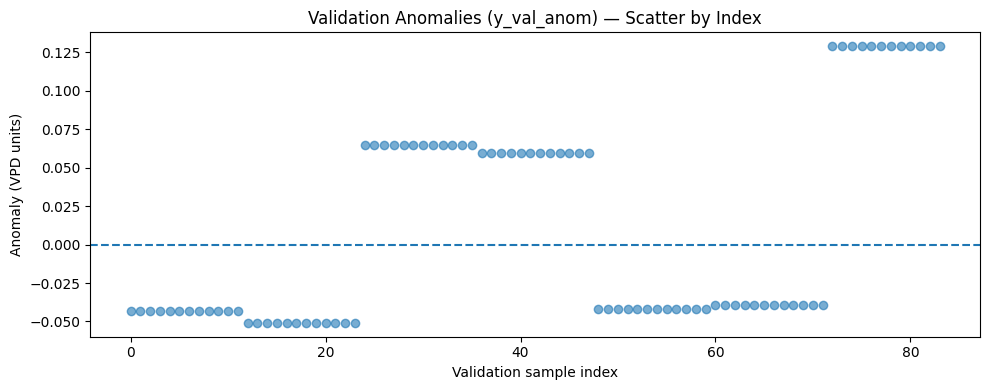


MAE by Horizon (Mean vs Quantile):



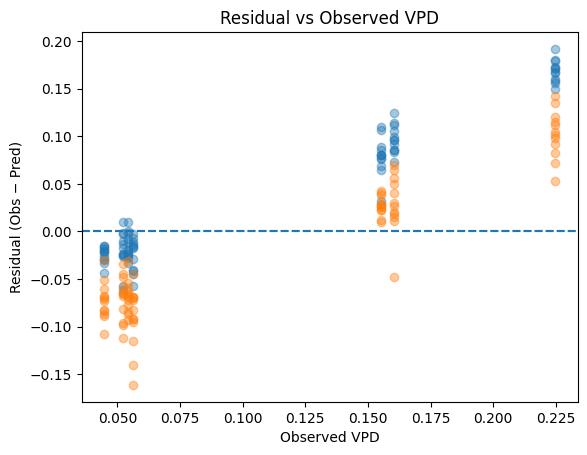

In [8]:


# ============================================================
# Predict (two-headed model)
# ============================================================
# =========================
# MODEL PREDICTION
# =========================

y_mean_pred, y_quantile_pred = model.predict(X_val)

y_mean_pred = y_mean_pred.reshape(-1)
y_quantile_pred = y_quantile_pred.reshape(-1)


# ============================================================
# Inverse-scale anomalies
# ============================================================
y_val_anom = y_scaler.inverse_transform(
    y_val.reshape(-1, 1)
).ravel()

y_mean_pred_anom = y_scaler.inverse_transform(
    y_mean_pred.reshape(-1, 1)
).ravel()

y_quantile_pred_anom = y_scaler.inverse_transform(
    y_quantile_pred.reshape(-1, 1)
).ravel()

plt.figure(figsize=(10,4))
plt.plot(y_val_anom, marker="o", linestyle="", alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Validation Anomalies (y_val_anom) — Scatter by Index")
plt.ylabel("Anomaly (VPD units)")
plt.xlabel("Validation sample index")
plt.tight_layout()
plt.show()

# ============================================================
# Add monthly means back (physical VPD)
# ============================================================
monthly_mean_dict = monthly_mean.to_dict()

y_val_phys = np.array([
    y_val_anom[i] + monthly_mean_dict[meta_month_val[i]]
    for i in range(len(y_val_anom))
])

y_mean_pred_phys = np.array([
    y_mean_pred_anom[i] + monthly_mean_dict[meta_month_val[i]]
    for i in range(len(y_mean_pred_anom))
])

y_quantile_pred_phys = np.array([
    y_quantile_pred_anom[i] + monthly_mean_dict[meta_month_val[i]]
    for i in range(len(y_quantile_pred_anom))
])


# ============================================================
# Helper: full evaluation
# ============================================================
def evaluate_head(name, y_pred_phys, regime_months):
    errors = y_val_phys - y_pred_phys
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt(np.mean(errors ** 2))
    
    plt.scatter(y_val_phys, errors, alpha=0.4)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Observed VPD")
    plt.ylabel("Residual (Obs − Pred)")
    plt.title("Residual vs Observed VPD")



    # print(regime_months.dtype)
    # print(type(regime_months[0]), regime_months[0])

 #   regime_mask = np.isin( np.array(regime_months),meta_month_val)
    regime_mask = np.zeros_like(meta_month_val, dtype=bool)
    for m in REGIME_MONTHS:
        regime_mask |= (meta_month_val == m)



    regime_mae = abs_errors[regime_mask].mean() if regime_mask.any() else np.nan

    rank_corr = np.nan
    if regime_mask.sum() > 2:
        obs = y_val_phys[regime_mask]
        pred = y_pred_phys[regime_mask]
        obs_rank = np.argsort(np.argsort(obs))
        pred_rank = np.argsort(np.argsort(pred))
        rank_corr = np.corrcoef(obs_rank, pred_rank)[0, 1]

    q90 = np.percentile(y_val_phys, 90)
    extreme_mask = y_val_phys >= q90
    extreme_bias = (
        np.mean(y_pred_phys[extreme_mask] - y_val_phys[extreme_mask])
        if extreme_mask.any() else np.nan
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Regime_MAE": regime_mae,
        "Regime_Rank": rank_corr,
        "Extreme_Bias": extreme_bias
    }


# ============================================================
# Run evaluation
# ============================================================
mean_metrics = evaluate_head("MEAN", y_mean_pred_phys, REGIME_MONTHS)
quantile_metrics = evaluate_head("QUANTILE", y_quantile_pred_phys, REGIME_MONTHS)

# ============================================================
# SIDE-BY-SIDE SUMMARY
# ============================================================
fout=open(f"{REGIME_NAME}_delta_vpd_resid.txt","w")

fout.write(f"\n================ {REGIME_NAME.upper()} TWO-HEAD COMPARISON =================\n")
fout.write(f"{'Metric':<20} {'Mean Head':>12} {'Quantile Head':>15}\n")
fout.write("-" * 50 + "\n")

for key in mean_metrics:
    fout.write(
        f"{key:<20} "
        f"{mean_metrics[key]:>12.3f} "
        f"{quantile_metrics[key]:>15.3f}\n"
    )

# ============================================================
# MAE BY HORIZON (OPTIONAL BUT IDENTICAL)
# ============================================================
print(f"\nMAE by Horizon (Mean vs Quantile):\n")
# Containers for pooled August diagnostics
all_delta_vpd = []
all_abs_resid = []
all_horizon = []
for h in sorted(np.unique(meta_horizon_val)):
    mask = meta_horizon_val == h

    # --- existing metrics (unchanged) ---
    resid_mean = y_val_phys[mask] - y_mean_pred_phys[mask]
    resid_quant = y_val_phys[mask] - y_quantile_pred_phys[mask]

    mae_mean = np.abs(resid_mean).mean()
    mae_quant = np.abs(resid_quant).mean()

    fout.write(
        f"  h={h:2d} → Mean={mae_mean:.3f} | Quantile={mae_quant:.3f}\n"
    )

    # --- NEW: ΔVPD diagnostics (mean head only is enough) ---
    y_obs = y_val_phys[mask]

    # IMPORTANT: ensure time order inside horizon
    # If you have target timestamps, uncomment and use:
    # order = np.argsort(meta_target_time_val[mask])
    # y_obs = y_obs[order]
    # resid_mean = resid_mean[order]

    # Compute ΔVPD safely within this horizon
    delta_vpd = np.empty_like(y_obs)
    delta_vpd[0] = np.nan
    delta_vpd[1:] = y_obs[1:] - y_obs[:-1]

    valid = ~np.isnan(delta_vpd)

    # Pool for later analysis
    all_delta_vpd.append(delta_vpd[valid])
    all_abs_resid.append(np.abs(resid_mean[valid]))
    all_horizon.append(np.full(np.sum(valid), h))


    # plt.figure(figsize=(4,4))
    # plt.scatter(
    #     y_val_phys[mask],
    #     y_mean_pred_phys[mask],
    #     alpha=0.6
    # )
    # plt.plot(
    #     [y_val_phys[mask].min(), y_val_phys[mask].max()],
    #     [y_val_phys[mask].min(), y_val_phys[mask].max()],
    #     "k--"
    # )
    # plt.xlabel("Observed VPD")
    # plt.ylabel("Predicted VPD (Mean)")
    # plt.title(f"Horizon h={h}")
    # plt.grid(alpha=0.3)
    # plt.tight_layout()
    # plt.show()

# Full-period monthly statistics (POR)
# df["month"] = df["Yrmo"] % 100

# ============================================================
# NORMALIZED MAE (POST-HOC DIAGNOSTICS, FULL POR)
# ============================================================

# Ensure month column exists (safe even if already present)
# if "month" not in df.columns:
#     df["month"] = df["Yrmo"] % 100

# # --- FULL PERIOD (POR) monthly climatology ---
# monthly_stats_por = (
#     df
#     .groupby("month")["VPD"]
#     .agg(
#         mean_VPD="mean",
#         std_VPD="std"
#     )
# )

# # ------------------------------------------------------------
# # NORMALIZE ML MAE (TEST ONLY, already computed upstream)
# # ------------------------------------------------------------
# ml_norm = ml_mae_by_month.to_frame("MAE")

# ml_norm["mean_VPD"] = monthly_stats_por["mean_VPD"]
# ml_norm["std_VPD"]  = monthly_stats_por["std_VPD"]

# ml_norm["MAE_over_mean"] = ml_norm["MAE"] / ml_norm["mean_VPD"]
# ml_norm["MAE_over_std"]  = ml_norm["MAE"] / ml_norm["std_VPD"]

# # ------------------------------------------------------------
# # WRITE NORMALIZED RESULTS TO SAME OUTPUT FILE
# # ------------------------------------------------------------
# fout = open(f"{REGIME_NAME}_delta_vpd_resid.txt", "a")

# fout.write("\n--- NORMALIZED ML MAE (TEST, FULL POR CLIMATOLOGY) ---\n")
# fout.write(f"{'Month':>5} {'MAE':>10} {'MAE/Mean':>12} {'MAE/Std':>12}\n")
# fout.write("-" * 45 + "\n")

# for m in ml_norm.index:
#     fout.write(
#         f"{m:5d} "
#         f"{ml_norm.loc[m,'MAE']:10.3f} "
#         f"{ml_norm.loc[m,'MAE_over_mean']:12.3f} "
#         f"{ml_norm.loc[m,'MAE_over_std']:12.3f}\n"
#     )

#fout.close()


# all_delta_vpd = np.concatenate(all_delta_vpd)
# all_abs_resid = np.concatenate(all_abs_resid)
# all_horizon = np.concatenate(all_horizon)

# plt.figure(figsize=(6,5))
# sc = plt.scatter(all_delta_vpd, all_abs_resid, c=all_horizon, cmap="viridis", alpha=0.6)
# plt.colorbar(sc, label="Horizon")
# plt.xlabel("ΔVPD")
# plt.ylabel("|Residual|")
# plt.title("June pooled residuals vs ΔVPD (colored by horizon)")
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()


corr = np.corrcoef(all_delta_vpd, all_abs_resid)[0,1]
fout.write(f"Corr(|residual|, ΔVPD) = {corr}\n")

fout.close()

## Sarima


In [8]:
def evaluate_sarima_monthly(
    df,TARGET_COL,FEATURE_COLS,
    value_col="VPD",
    date_col="Yrmo",
    order=(1, 0, 0),
    seasonal_order=(0, 1, 1, 12),
):
    """
    Drop-in SARIMA evaluation aligned with ML.

    - Uses RAW VPD (no scaling, no anomalies)
    - Uses EXACT ML train/test split
    - Computes MAE ONLY on test split
    - Produces MONTHLY MAE (Jan–Dec)

    Parameters
    ----------
    df : pandas.DataFrame
        Full dataset used by ML
    train_end_yrmo : int
        Last YYYYMM used for training (same as ML)
    value_col : str
        Raw VPD column
    date_col : str
        YYYYMM column
    order : tuple
        SARIMA (p,d,q)
    seasonal_order : tuple
        SARIMA (P,D,Q,s)

    Returns
    -------
    dict with:
        - total_mae
        - mae_by_month (pd.Series indexed 1–12)
        - sarima_model (fitted object)
    """

    import numpy as np
    import pandas as pd
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    X=df[FEATURE_COLS].values.astype(np.float32)
    y=df[TARGET_COL].values.astype(np.float32)
    # ------------------------------------------------------------------
    # 1. Exact ML train/test split
    # ------------------------------------------------------------------
    X_train, X_val, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=False
    )

    # ------------------------------------------------------------------
    # 2. Fit SARIMA on TRAIN ONLY (raw VPD)
    # ------------------------------------------------------------------
    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    res = model.fit(disp=False)

    # ------------------------------------------------------------------
    # 3. Forecast EXACT test window
    # ------------------------------------------------------------------
    y_pred = res.forecast(steps=len(y_test))

    # ------------------------------------------------------------------
    # 4. Compute MAE ONLY on test split
    # ------------------------------------------------------------------
    abs_err = np.abs(y_test - y_pred)
    total_mae = abs_err.mean()

    # ------------------------------------------------------------------
    # 5. Monthly MAE (target-month based)
    # ------------------------------------------------------------------
    test_df = df[len(y_train):].copy()
    test_df["abs_err"] = abs_err
    test_df["month"] = test_df[date_col] % 100

    mae_by_month = (
        test_df
        .groupby("month")["abs_err"]
        .mean()
        .sort_index()
    )

    return {
        "total_mae": total_mae,
        "mae_by_month": mae_by_month,
        "sarima_model": res,
    }



sarima_results = evaluate_sarima_monthly(
    df=df,TARGET_COL=TARGET_COL,FEATURE_COLS=FEATURE_COLS, # EXACT ML cutoff
    order=(1, 0, 0),                 # <-- your existing SARIMA
    seasonal_order=(0, 1, 1, 12),    # <-- your existing SARIMA
)

print("SARIMA test MAE:", sarima_results["total_mae"])
print("\nSARIMA monthly MAE:")
print(sarima_results["mae_by_month"])



SARIMA test MAE: 0.1667792668652766

SARIMA monthly MAE:
month
1     0.019585
2     0.025722
3     0.123533
4     0.109498
5     0.185356
6     0.306145
7     0.247572
8     0.297685
9     0.346873
10    0.215989
11    0.059715
12    0.063678
Name: abs_err, dtype: float64


In [38]:
dv = all_delta_vpd
ar = all_abs_resid

# Define bands by rounding ΔVPD (adjust decimals if needed)
dv_band = np.round(dv, 3)

bands = np.unique(dv_band)

rows = []
for b in bands:
    mask = dv_band == b
    rows.append({
        "ΔVPD": b,
        "n": mask.sum(),
        "mean_abs_resid": np.mean(ar[mask]),
        "median_abs_resid": np.median(ar[mask])
    })

# Sort by ΔVPD
rows = sorted(rows, key=lambda x: x["ΔVPD"])

# Print table
print(f"{'ΔVPD':>8} {'n':>4} {'mean|resid|':>12} {'median|resid|':>14}")
for r in rows:
    print(
        f"{r['ΔVPD']:8.3f} "
        f"{r['n']:4d} "
        f"{r['mean_abs_resid']:12.3f} "
        f"{r['median_abs_resid']:14.3f}"
    )

    ΔVPD    n  mean|resid|  median|resid|
  -0.898   11        0.425          0.440
  -0.449   24        0.262          0.154
   0.412   12        0.106          0.073
   0.523   12        0.240          0.249
   0.528   12        0.502          0.494


In [23]:
regime_mask = np.zeros_like(meta_month_val, dtype=bool)
for m in REGIME_MONTHS:
    regime_mask |= (meta_month_val == m)

print(regime_mask)


[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  T

In [10]:
def evaluate_head(name, y_pred_phys):
    errors = y_val_phys - y_pred_phys
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt(np.mean(errors ** 2))

    # July diagnostics
    july_mask = meta_month_val == 7
    july_mae = abs_errors[july_mask].mean()

    rank_corr = np.nan
    if july_mask.sum() > 2:
        obs = y_val_phys[july_mask]
        pred = y_pred_phys[july_mask]
        obs_rank = np.argsort(np.argsort(obs))
        pred_rank = np.argsort(np.argsort(pred))
        rank_corr = np.corrcoef(obs_rank, pred_rank)[0, 1]

    # Extreme bias
    q90 = np.percentile(y_val_phys, 90)
    extreme_mask = y_val_phys >= q90
    extreme_bias = np.mean(
        y_pred_phys[extreme_mask] - y_val_phys[extreme_mask]
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "July_MAE": july_mae,
        "July_Rank": rank_corr,
        "Extreme_Bias": extreme_bias
    }


In [11]:
mean_metrics = evaluate_head("MEAN", y_mean_pred_phys)
quant_metrics = evaluate_head("QUANTILE", y_quantile_pred_phys)

print("\n================ TWO-HEAD COMPARISON =================")
print(f"{'Metric':<20} {'Mean Head':>12} {'Quantile Head':>15}")
print("-" * 50)

for k in mean_metrics:
    print(f"{k:<20} {mean_metrics[k]:>12.3f} {quant_metrics[k]:>15.3f}")



================ TWO-HEAD COMPARISON =================
Metric                  Mean Head   Quantile Head
--------------------------------------------------
MAE                         0.224           0.094
RMSE                        0.246           0.117
July_MAE                    0.224           0.094
July_Rank                  -0.061           0.212
Extreme_Bias               -0.298           0.023


## Ensemble

In [7]:
def evaluate_head(
    y_true_phys: np.ndarray,
    y_pred_phys: np.ndarray,
    meta_month_val: np.ndarray,
    meta_horizon_val: np.ndarray,
    *,
    focus_month: int | None = 7,
    enable_extreme_gate: bool = True,
    extreme_percentile: float = 90.0,
) -> dict:
    """
    Evaluate predictions in physical units.

    Args:
      y_true_phys, y_pred_phys: arrays shape (N,)
      meta_month_val, meta_horizon_val: arrays shape (N,)
      focus_month: month for month-specific diagnostics (None disables)
      enable_extreme_gate: on/off for extreme diagnostics
      extreme_percentile: percentile threshold computed on y_true_phys (global)

    Returns:
      dict of metrics comparable to earlier evaluation.
    """
    y_true_phys = np.asarray(y_true_phys).reshape(-1)
    y_pred_phys = np.asarray(y_pred_phys).reshape(-1)

    if y_true_phys.shape != y_pred_phys.shape:
        raise ValueError(f"Shape mismatch: y_true {y_true_phys.shape} vs y_pred {y_pred_phys.shape}")

    errors = y_true_phys - y_pred_phys
    abs_errors = np.abs(errors)

    mae = float(abs_errors.mean())
    rmse = float(np.sqrt(np.mean(errors ** 2)))

    # Month diagnostics (default July)
    month_mae = np.nan
    rank_corr = np.nan
    if focus_month is not None:
        m_mask = (meta_month_val == focus_month)
        if m_mask.any():
            month_mae = float(abs_errors[m_mask].mean())
            if m_mask.sum() > 2:
                obs = y_true_phys[m_mask]
                pred = y_pred_phys[m_mask]
                obs_rank = np.argsort(np.argsort(obs))
                pred_rank = np.argsort(np.argsort(pred))
                rank_corr = float(np.corrcoef(obs_rank, pred_rank)[0, 1])

    # Extreme diagnostics gate
    extreme_bias = np.nan
    if enable_extreme_gate:
        thr = np.percentile(y_true_phys, extreme_percentile)
        extreme_mask = y_true_phys >= thr
        if extreme_mask.any():
            extreme_bias = float(np.mean(y_pred_phys[extreme_mask] - y_true_phys[extreme_mask]))

    return {
        "MAE": mae,
        "RMSE": rmse,
        f"{'July' if focus_month==7 else 'Month'}_MAE": month_mae,
        f"{'July' if focus_month==7 else 'Month'}_Rank": rank_corr,
        "Extreme_Bias": extreme_bias,
    }

In [9]:
N_ENSEMBLE = 10
ensemble_results = []
monthly_mean_dict = monthly_mean.to_dict()
for k in range(N_ENSEMBLE):
    tf.keras.backend.clear_session()
    tf.random.set_seed(100 + k)
    np.random.seed(100 + k)
    print("ENSEMBLE MEMBER", k)
    model = build_two_head_nn(X_train.shape[1])
    model.fit(
        X_train,
        {"mean": y_train, "quantile": y_train},
        validation_data=(X_val, {"mean": y_val, "quantile": y_val}),
        epochs=20,
        callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
        verbose=0
    )

    pred_mean, pred_quantile = model.predict(X_val)

    pred_mean = pred_mean.ravel()
    pred_quantile = pred_quantile.ravel()

    mean_anom = y_scaler.inverse_transform(pred_mean[:, None]).ravel()
    quant_anom = y_scaler.inverse_transform(pred_quantile[:, None]).ravel()
    y_obs_anom = y_scaler.inverse_transform(y_val[:, None]).ravel()

    mean_phys = np.array([
        mean_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(mean_anom))
    ])

    quant_phys = np.array([
        quant_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(quant_anom))
    ])

    obs_phys = np.array([
        y_obs_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_obs_anom))
    ])

    mean_metrics = evaluate_head(
        obs_phys, mean_phys,
        meta_month_val, meta_horizon_val,
        focus_month=7,
        enable_extreme_gate=True,
        extreme_percentile=90
    )

    quant_metrics = evaluate_head(
        obs_phys, quant_phys,
        meta_month_val, meta_horizon_val,
        focus_month=7,
        enable_extreme_gate=True,
        extreme_percentile=90
    )

    ensemble_results.append({"member": k, "head": "mean", **mean_metrics})
    ensemble_results.append({"member": k, "head": "quantile", **quant_metrics})


ENSEMBLE MEMBER 0


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7b37c03efba0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
ENSEMBLE MEMBER 1
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
ENSEMBLE MEMBER 2
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
ENSEMBLE MEMBER 3
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
ENSEMBLE MEMBER 4
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
ENSEMBLE MEMBER 5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
ENSEMBLE MEMBER 6
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
ENSEMBLE MEMBER 7
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
ENSEMBLE MEMBER 8
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
ENSEMBLE MEMBER 9
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


In [10]:
ensemble_results

[{'member': 0,
  'head': 'mean',
  'MAE': 0.2383691966533661,
  'RMSE': 0.26047393679618835,
  'July_MAE': 0.2383691966533661,
  'July_Rank': -0.05879266193694638,
  'Extreme_Bias': -0.27917206287384033},
 {'member': 0,
  'head': 'quantile',
  'MAE': 0.09259501844644547,
  'RMSE': 0.11436363309621811,
  'July_MAE': 0.09259501844644547,
  'July_Rank': 0.11821502036018638,
  'Extreme_Bias': 0.03323899582028389},
 {'member': 1,
  'head': 'mean',
  'MAE': 0.23609007894992828,
  'RMSE': 0.2578151524066925,
  'July_MAE': 0.23609007894992828,
  'July_Rank': -0.1963813441920994,
  'Extreme_Bias': -0.28632310032844543},
 {'member': 1,
  'head': 'quantile',
  'MAE': 0.10823196172714233,
  'RMSE': 0.13461816310882568,
  'July_MAE': 0.10823196172714233,
  'July_Rank': -0.12690483187103815,
  'Extreme_Bias': -0.013088161125779152},
 {'member': 2,
  'head': 'mean',
  'MAE': 0.21946237981319427,
  'RMSE': 0.23796691000461578,
  'July_MAE': 0.21946237981319427,
  'July_Rank': -0.06647495906972839,
  '